In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.formula.api as smf

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
import scipy
print(f"scipy: {scipy.__version__}")
import statsmodels
print(f"statsmodels: {statsmodels.__version__}")

pd.set_option('display.max_columns', None)

pandas: 2.3.3
numpy: 2.3.4
matplotlib: 3.10.7
seaborn: 0.13.2
scipy: 1.16.3
statsmodels: 0.14.5


In [2]:
## define path
basedir = "/Users/kyokokurihara/iLab/itolab_backup/backup-latest/Lab/projects/2507blastx"

# output directory
path_out = f"{basedir}/output/250909_4474_samples/final_test/"
# sub folder
sub_out_group = path_out + "group_analysis/"
sub_out_chaphama = sub_out_group + "chaphama/"

# input files
# sample info table
sradata_path = f"{basedir}/data/Infection_Prediction_Stacking_0_sample_list_TN1000.txt"
sradata_ex_path = f"{basedir}/data/data_external_251110/sample_list_cuttlefish_minia_diamond_add_positive0to2_blastx_all.txt"
# metatable
meta_in = f"{basedir}/output/250909_4474_samples/final_test/virus_all.blastn.tsv"
# ISG score
isg_score_path = f"{basedir}/data/isg_level_annotation/Aves_Mam_mbio_250613_ISGscore_logan.txt"
isg_score_all_path = f"{basedir}/data/isg_level_annotation/Aves_Mam_mbio_250613.ISGcntl_norm_logan.txt"
# run selector
run_selector_chaphama_path = f"{basedir}/data/Chaphamaparvovirus_bioproject/"
run_selector_chaphama_path_blastx_filtered = f"{sub_out_group}/Chaphamaparvovirus_bioproject_260224_project_added/"  # output
# blastx result path
blast_res_path = f"{basedir}/output/250909_4474_samples/group_analysis/260209_blastx/virus_all.txt"
blast_res_path_added = f"{basedir}/output/250909_4474_samples/group_analysis/260302_blastx/virus_all.txt"
blast_input_path = f"{basedir}/output/250909_4474_samples/group_analysis/samples_to_blastx/samples_to_run_blastx_260202.tsv"
# project metadata path
project_meta_path = f"{basedir}/data/projects_of_interest_parvovirus_Chaphamaparvovirus_clade_edited.tsv"

if not os.path.exists(path_out):
    os.mkdir(path_out)
if not os.path.exists(sub_out_group):
    os.mkdir(sub_out_group)
if not os.path.exists(sub_out_chaphama):
    os.mkdir(sub_out_chaphama)
if not os.path.exists(run_selector_chaphama_path_blastx_filtered):
    os.mkdir(run_selector_chaphama_path_blastx_filtered)
print("saving files:", sub_out_chaphama)

saving files: /Users/kyokokurihara/iLab/itolab_backup/backup-latest/Lab/projects/2507blastx/output/250909_4474_samples/final_test/group_analysis/chaphama/


# Read ISG score table

In [3]:
# read ISG level annotaiton table
df_isg_score_raw = pd.read_table(isg_score_path)
df_isg_score_raw["source_table"] = "Logan"

# extract IRF7 and STAT1 (run once)
df_isg_all_genes = pd.read_table(isg_score_all_path)
df_isg_gene_of_interest = df_isg_all_genes.loc[df_isg_all_genes["hum_symbol"].isin(["IRF7", "STAT1"]), :].copy()
# save
df_isg_gene_of_interest.to_csv(sub_out_group + "IRF7_STAT1_from_Aves_Mam_mbio_250613.ISGcntl_norm_logan.txt", sep="\t")
# show
df_isg_gene_of_interest.head(3)

,hum_symbol,type,hum_geneID,sum_salmon,all_sum,cntl_sum,ID,norm_genes,norm_genes_log,Host_species,BioProject_ID,Infection,species,tax_id,kingdom,phylum,class,order,family,genus,nucleotide_DNA,nucleotide_RNA,ISG_level,mean_norm_genes_log,sd_norm_genes_log,ISG_score
16,IRF7,ISG,3665,2280.000,2644484.991,2275392.382,ERR10125124,0.001002,9.970142,Gallus_gallus,PRJEB55656,Positive,Gallus_gallus,9031,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,Gallus,Negative,Positive,high,7.865383,2.804940,0.750376
38,STAT1,ISG,6772,11812.211,2644484.991,2275392.382,ERR10125124,0.005191,12.342154,Gallus_gallus,PRJEB55656,Positive,Gallus_gallus,9031,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,Gallus,Negative,Positive,high,11.344646,2.056357,0.485085
168,IRF7,ISG,3665,258.000,2017073.986,1891205.508,ERR10125126,0.000136,7.102458,Gallus_gallus,PRJEB55656,Positive,Gallus_gallus,9031,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,Gallus,Negative,Positive,high,7.865383,2.804940,-0.271993


In [4]:
# read IRF7 and STAT1 table
df_isg_gene_of_interest = pd.read_table(sub_out_group + "IRF7_STAT1_from_Aves_Mam_mbio_250613.ISGcntl_norm_logan.txt", index_col=0)
# add IRF7
df_isg_irf7 = df_isg_gene_of_interest.loc[df_isg_gene_of_interest["hum_symbol"]=="IRF7", :][["ID", "ISG_score"]].copy()
df_isg_irf7.columns = df_isg_irf7.columns.map(lambda x: x.replace("ISG_score", "ISG_score_IRF7"))
# add STAT1
df_isg_stat1 = df_isg_gene_of_interest.loc[df_isg_gene_of_interest["hum_symbol"]=="STAT1", :][["ID", "ISG_score"]].copy()
df_isg_stat1.columns = df_isg_stat1.columns.map(lambda x: x.replace("ISG_score", "ISG_score_STAT1"))
# merge mean ISG, IRF7, STAT1
df_isg_score = df_isg_score_raw.merge(df_isg_irf7, on="ID", how="left")
df_isg_score = df_isg_score.merge(df_isg_stat1, on="ID", how="left")
print("size after merging:", df_isg_score.shape)
# show
df_isg_score.head(3)

size after merging: (168438, 20)


,ID,ISG_mean,all_sum,Host_species,BioProject_ID,Infection,species,tax_id,kingdom,phylum,class,order,family,genus,nucleotide_DNA,nucleotide_RNA,ISG_level,source_table,ISG_score_IRF7,ISG_score_STAT1
0,ERR10125124,0.139505,2644484.991,Gallus_gallus,PRJEB55656,Positive,Gallus_gallus,9031,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,Gallus,Negative,Positive,high,Logan,0.750376,0.485085
1,ERR10125126,-0.298822,2017073.986,Gallus_gallus,PRJEB55656,Positive,Gallus_gallus,9031,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,Gallus,Negative,Positive,high,Logan,-0.271993,0.012092
2,ERR10125127,-0.327027,2515563.984,Gallus_gallus,PRJEB55656,Positive,Gallus_gallus,9031,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,Gallus,Negative,Positive,high,Logan,-0.157795,0.061288


# Sample selection

In [5]:
# check if samples are analyzed in blastx
ml_out = pd.read_table(sradata_path)
samples_in_blastx_analysis = set(ml_out["ID"])

# check if blastx result reported the Parvovididae family ->edit the table
target_family = "Parvoviridae"
# read blastx result
df = pd.read_table(meta_in, dtype={"Project_Id": "Int64"}, index_col=0)
blast_res = pd.read_table(blast_res_path, index_col=0)  # read extra blast result
blast_res_added = pd.read_table(blast_res_path_added, index_col=0)  ## added on 260302
blast_res = pd.concat([blast_res, blast_res_added])
target_samples = set(blast_res.loc[blast_res["family"]==target_family, "sample"].to_list())
target_samples_internal = set(df.loc[df["family"]==target_family, "sample"].to_list())
target_samples_all = sorted(list(target_samples | target_samples_internal))
blast_input = pd.read_table(blast_input_path)
blast_input_samples = sorted(list(set(blast_input["Run"].to_list())))

# update negative samples based on blastx result
for dirpath, dirnames, filenames in os.walk(run_selector_chaphama_path):
    if "archived" in dirpath:   # skip archived directory
        continue
    for filename in filenames:
        if not (filename.startswith("SraRunTable")):  # to pass metatable
            continue

        # full path to each blast output file
        full_path = os.path.join(dirpath, filename)
        # read table
        sra_run_table = pd.read_csv(full_path)
        # get project name
        project = list(set(sra_run_table["BioProject"].to_list()))[0]
        print(f"\nProject_Id: {project}")
        # get positive and negative
        pos_lst = sra_run_table.loc[sra_run_table["Positive"]==1, "Run"].to_list()
        # get negative samples
        nega_lst = sra_run_table.loc[sra_run_table["Negative"]==1, "Run"].to_list()
        # get all samples
        pos_and_nega_ids = pos_lst + nega_lst

        # virus detected ID by blastx
        for sample_id in nega_lst:
            print("ID:", sample_id)
            if sample_id in target_samples_all:
                source = "NAN"
                if sample_id in target_samples:
                    source = "extra"
                    hit_num = blast_res.loc[(blast_res["family"]==target_family)&(blast_res["sample"]==sample_id), :].shape[0]
                if sample_id in target_samples_internal:
                    source = "internal"
                    hit_num = df.loc[(df["family"]==target_family)&(df["sample"]==sample_id), :].shape[0]
                print(f"### {sample_id} is NC but has {hit_num} ({source}) {target_family} ###")
                sra_run_table.loc[sra_run_table["Run"]==sample_id, "Negative"] = 0
                print("removed this sample from negative control annotaiton")
            if (sample_id not in samples_in_blastx_analysis) and (sample_id not in blast_input_samples) and (sample_id not in ["SRR18919716", "SRR18919720"]):  ##perfomed individually 
                print(f"---{sample_id} not analyzed by blastx---")  ##
        # save with NC samples without blastx hit
        sra_run_table.to_csv(run_selector_chaphama_path_blastx_filtered + filename)


Project_Id: PRJNA631786
ID: SRR24318018
### SRR24318018 is NC but has 13 (extra) Parvoviridae ###
removed this sample from negative control annotaiton

Project_Id: PRJNA832079
ID: SRR18919716
### SRR18919716 is NC but has 3 (extra) Parvoviridae ###
removed this sample from negative control annotaiton
ID: SRR18919718
### SRR18919718 is NC but has 1 (internal) Parvoviridae ###
removed this sample from negative control annotaiton
ID: SRR18919719
ID: SRR18919720

Project_Id: PRJNA577590
ID: SRR10293992
ID: SRR10293993
ID: SRR10293994
ID: SRR10293995
ID: SRR10293996
ID: SRR10293997
ID: SRR10293998
ID: SRR10293999
ID: SRR10294000
ID: SRR10294001
ID: SRR10294003
ID: SRR10294004
ID: SRR10294005
ID: SRR10294006
ID: SRR10294007
ID: SRR10294008
### SRR10294008 is NC but has 5 (extra) Parvoviridae ###
removed this sample from negative control annotaiton
ID: SRR10294009
ID: SRR10294010
ID: SRR10294011

Project_Id: PRJNA170656
ID: SRR521358
ID: SRR521360

Project_Id: PRJNA845131
ID: SRR19545583
###

In [6]:
# ISG score (positive vs negative)
first_file = True
for dirpath, dirnames, filenames in os.walk(run_selector_chaphama_path_blastx_filtered):  ##
    if "archived" in dirpath:   # skip archived directory
        continue
    for filename in filenames:
        if not (filename.startswith("SraRunTable")):  # to pass metatable
            continue

        # full path to each blast output file
        full_path = os.path.join(dirpath, filename)
        # read table
        sra_run_table = pd.read_csv(full_path)
        # get project name
        project_lst = list(set(sra_run_table["BioProject"].to_list()))
        project = project_lst[0]
        print(f"\nProject_Id: {project}")
        # check if project id is unique
        if len(project_lst) != 1:
            print(f"multiple BioProject included in the table {full_path}")

        # get positive samples
        pos_lst = sra_run_table.loc[sra_run_table["Positive"]==1, "Run"].to_list()
        print("Positive samples:", pos_lst)
        # get negative samples
        nega_lst = sra_run_table.loc[sra_run_table["Negative"]==1, "Run"].to_list()
        print("Negative samples:", nega_lst)

        # find samples in isg meta table
        pos_meta = df_isg_score.loc[df_isg_score["ID"].isin(pos_lst), :].copy()
        pos_meta["blastx_res"] = "Positive" # add positive/negagtive annotation from blastx analysis
        if len(set(pos_meta["ID"].to_list()))!=len(pos_lst):
            print("### Number of sample IDs unmatched for positive group. ###")
        print("#Positive samples in RunSelector:", len(pos_lst))
        print("#Positive samples available:", df_isg_score.loc[df_isg_score["ID"].isin(pos_lst), :].groupby("ID").first().shape[0])
        print("Missing samples:", sorted(list(set(pos_lst) - set(df_isg_score.loc[df_isg_score["ID"].isin(pos_lst), :]["ID"].to_list()))))
        nega_meta = df_isg_score.loc[df_isg_score["ID"].isin(nega_lst), :].copy()
        nega_meta["blastx_res"] = "Negative"  # add positive/negagtive annotation from blastx analysis
        if len(set(nega_meta["ID"].to_list()))!=len(nega_lst):
            print("### Number of sample IDs unmatched for negative group. ###")
        print("#Negative samples in RunSelector:", len(nega_lst))
        print("#Negative samples available:", df_isg_score.loc[df_isg_score["ID"].isin(nega_lst), :].groupby("ID").first().shape[0])
        print("Missing samples:", sorted(list(set(nega_lst) - set(df_isg_score.loc[df_isg_score["ID"].isin(nega_lst), :]["ID"].to_list()))))

        # remove bioprojects without negative controls
        if df_isg_score.loc[df_isg_score["ID"].isin(nega_lst), :].groupby("ID").first().shape[0] < 1:  ##
            print(f"#### skipping {project} since it has no available negative samples")  ##
            continue

        # create dataframe for plot
        project_meta = pd.concat([pos_meta, nega_meta]).sort_values("blastx_res")
        # concat dataframe for later analysis
        if first_file:
            project_all = project_meta.copy()
            first_file = False
        else:
            project_all = pd.concat([project_all, project_meta])

# save table
project_all.to_csv(sub_out_chaphama + f"metatable_mean_isg_posvsnega_all_251202.tsv", sep="\t")


Project_Id: PRJNA631786
Positive samples: ['SRR24318017']
Negative samples: []
#Positive samples in RunSelector: 1
#Positive samples available: 1
Missing samples: []
#Negative samples in RunSelector: 0
#Negative samples available: 0
Missing samples: []
#### skipping PRJNA631786 since it has no available negative samples

Project_Id: PRJNA832079
Positive samples: ['SRR18919717']
Negative samples: ['SRR18919719', 'SRR18919720']
#Positive samples in RunSelector: 1
#Positive samples available: 1
Missing samples: []
#Negative samples in RunSelector: 2
#Negative samples available: 2
Missing samples: []

Project_Id: PRJNA577590
Positive samples: ['SRR10294002']
Negative samples: ['SRR10293992', 'SRR10293993', 'SRR10293994', 'SRR10293995', 'SRR10293996', 'SRR10293997', 'SRR10293998', 'SRR10293999', 'SRR10294000', 'SRR10294001', 'SRR10294003', 'SRR10294004', 'SRR10294005', 'SRR10294006', 'SRR10294007', 'SRR10294009', 'SRR10294010', 'SRR10294011']
#Positive samples in RunSelector: 1
#Positive s


====== mean_ISG ======
MixedLM:
              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    ISG_mean
No. Observations:    59         Method:                REML    
No. Groups:          6          Scale:                 0.0225  
Min. group size:     3          Log-Likelihood:        17.5106 
Max. group size:     19         Converged:             Yes     
Mean group size:     9.8                                       
---------------------------------------------------------------
                       Coef. Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept              0.015    0.088 0.174 0.862 -0.158  0.188
blastx_res[T.Positive] 0.175    0.056 3.116 0.002  0.065  0.285
Group Var              0.042    0.202                          

p value: Intercept                 0.862147
blastx_res[T.Positive]    0.001836
Group Var                 0.166749
dtype: float64


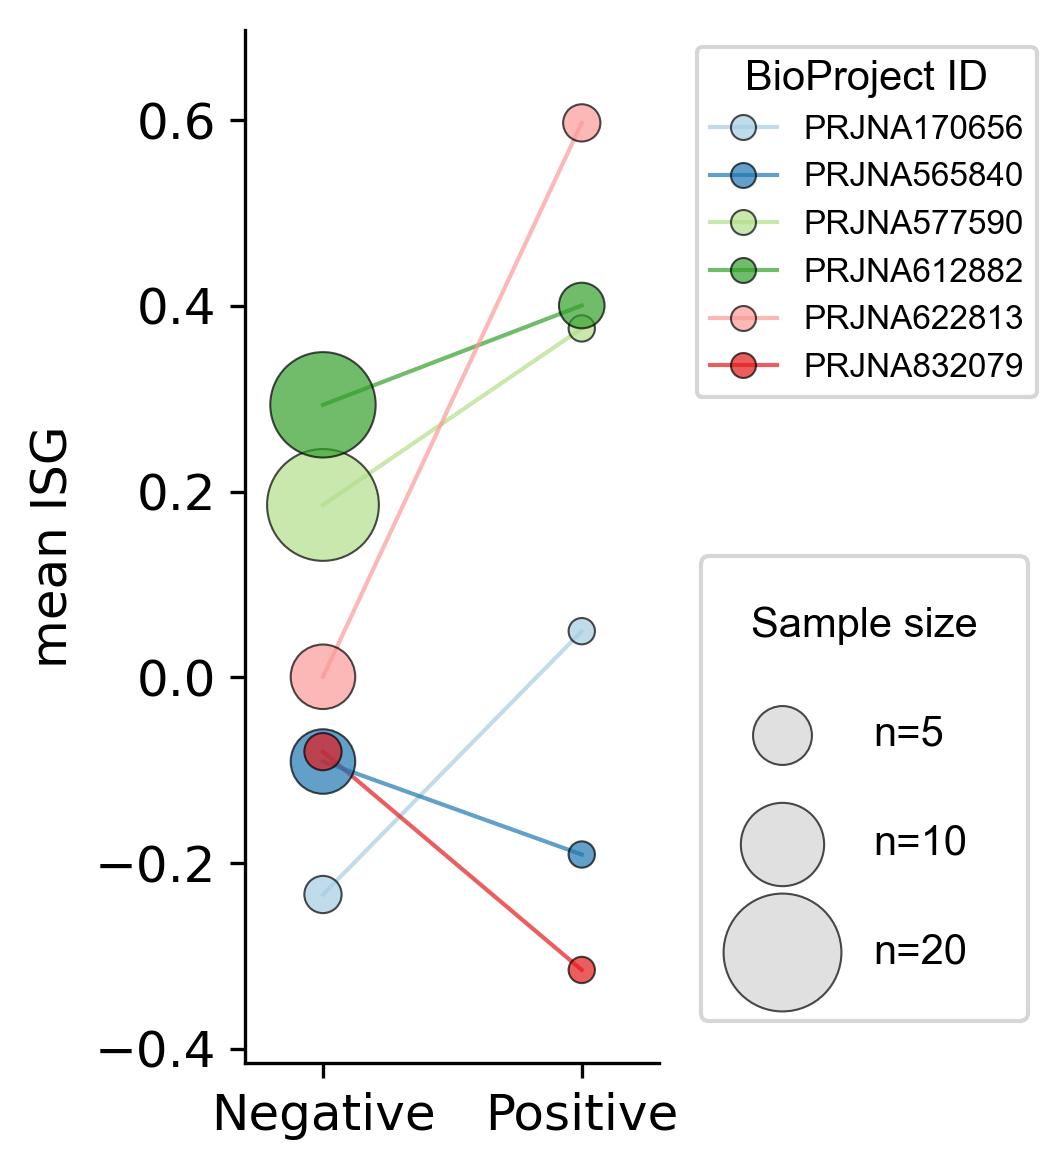


====== mean_IRF7 ======
MixedLM:
              Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  ISG_score_IRF7
No. Observations:  59       Method:              REML          
No. Groups:        6        Scale:               0.0313        
Min. group size:   3        Log-Likelihood:      5.5947        
Max. group size:   19       Converged:           Yes           
Mean group size:   9.8                                         
---------------------------------------------------------------
                       Coef. Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept              0.602    0.173 3.480 0.001  0.263  0.941
blastx_res[T.Positive] 0.164    0.066 2.481 0.013  0.034  0.293
Group Var              0.173    0.673                          

p value: Intercept                 0.000502
blastx_res[T.Positive]    0.013108
Group Var                 0.146466
dtype: float64


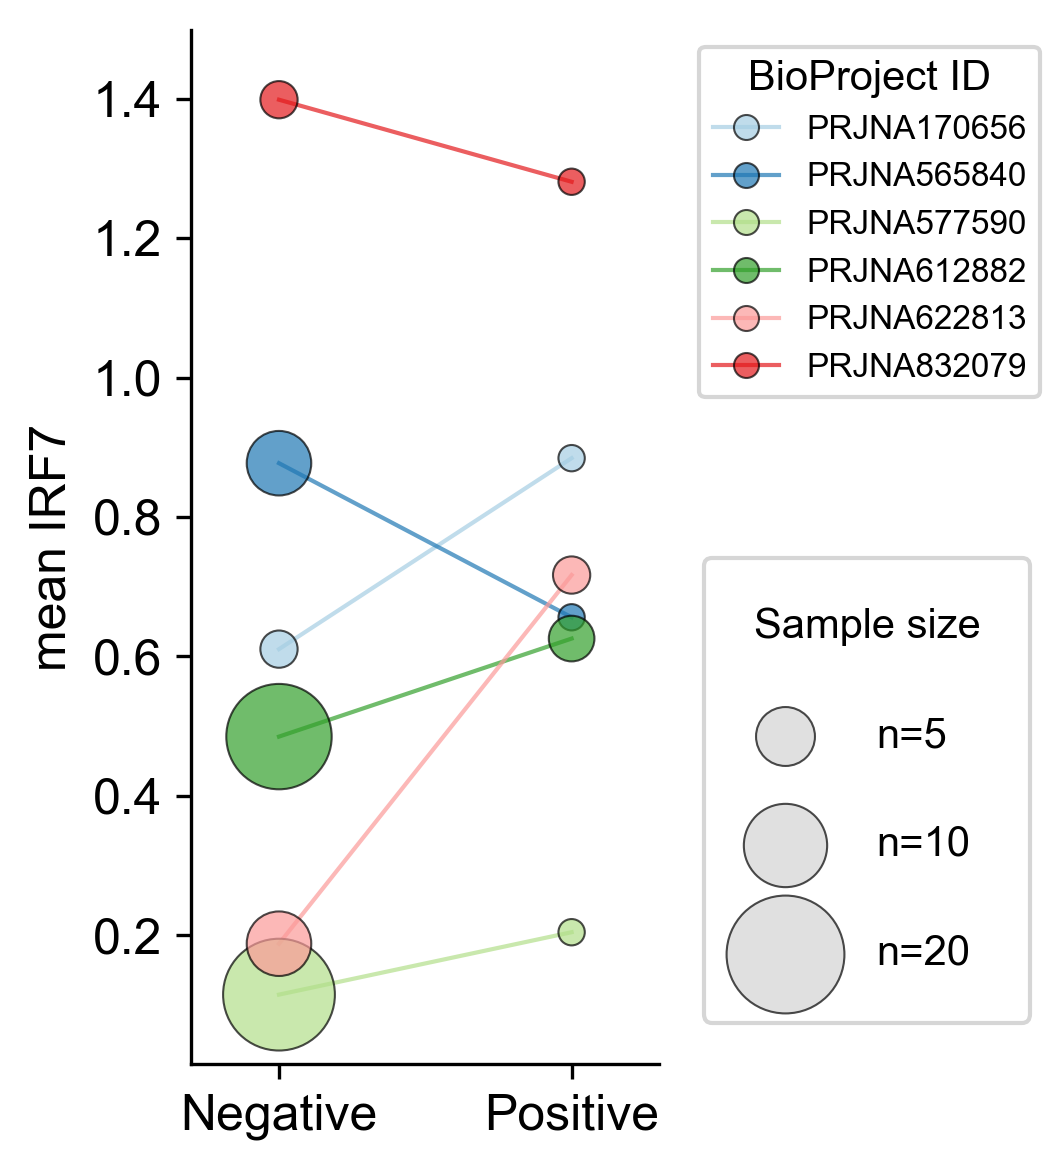


====== mean_STAT1 ======
MixedLM:
              Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: ISG_score_STAT1
No. Observations:   59      Method:             REML           
No. Groups:         6       Scale:              0.0954         
Min. group size:    3       Log-Likelihood:     -25.6580       
Max. group size:    19      Converged:          Yes            
Mean group size:    9.8                                        
---------------------------------------------------------------
                       Coef. Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept              0.075    0.271 0.276 0.782 -0.457  0.607
blastx_res[T.Positive] 0.576    0.115 4.995 0.000  0.350  0.802
Group Var              0.422    0.938                          

p value: Intercept                 7.824092e-01
blastx_res[T.Positive]    5.872931e-07
Group Var                 1.453523e-01
dtype: float64


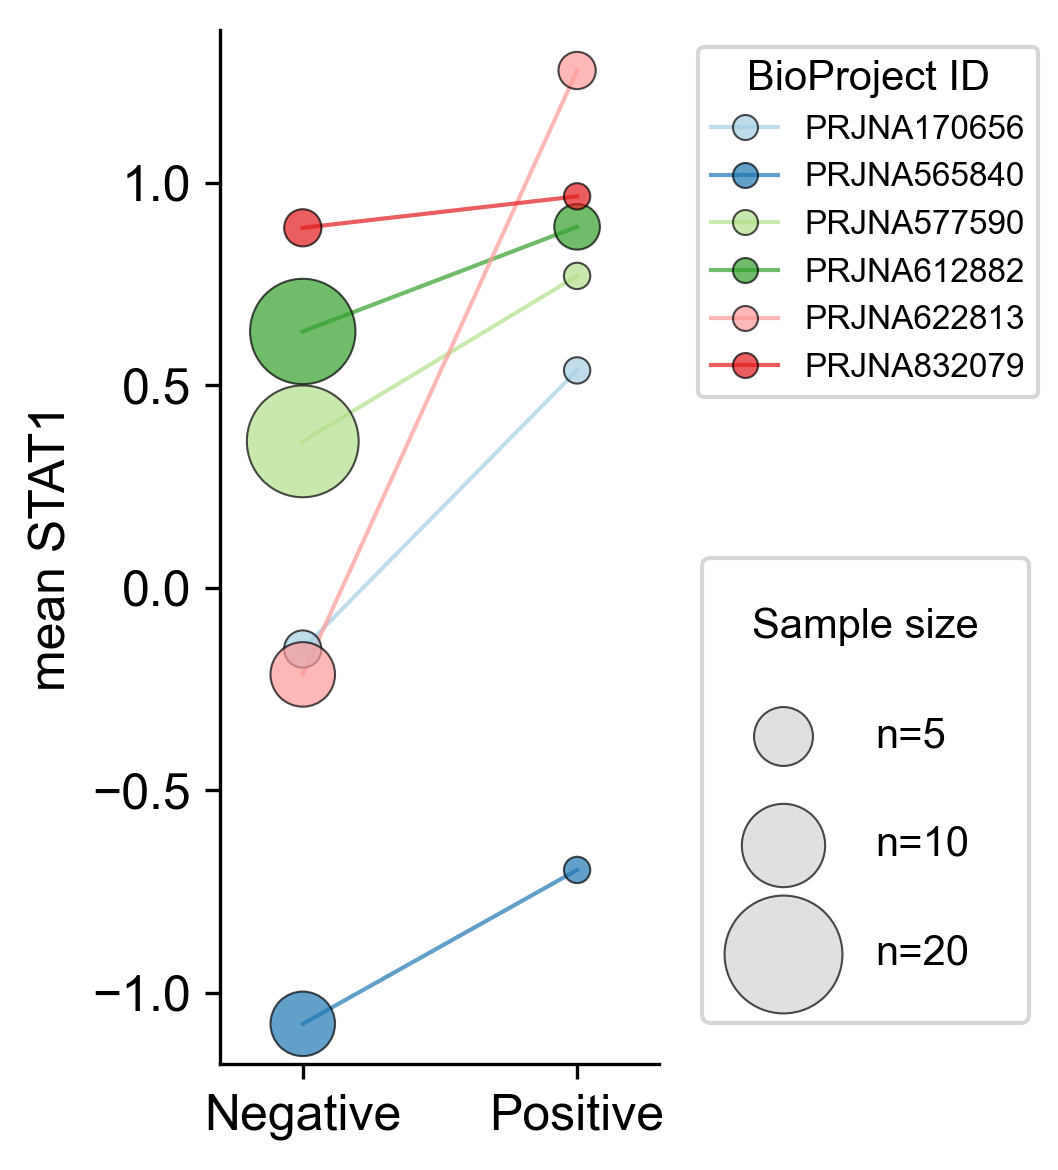

In [7]:
# plot all projects in one figure
# calculate mean per group
project_all_summary = project_all.groupby(["BioProject_ID", "blastx_res"]).agg(
    mean_ISG=("ISG_mean", "mean"),
    mean_IRF7=("ISG_score_IRF7", "mean"),
    mean_STAT1=("ISG_score_STAT1", "mean"),
    group_size=("ISG_mean", "size")
).reset_index()
project_all_summary.to_csv(sub_out_chaphama + "raw_values_for_plot_chaphama.tsv", sep="\t")

# make 3 plots
raw_col_name = {"mean_ISG": "ISG_mean", "mean_IRF7": "ISG_score_IRF7", "mean_STAT1":"ISG_score_STAT1"}
targets = ["mean_ISG", "mean_IRF7", "mean_STAT1"]

for target in targets:
    print(f"\n====== {target} ======")
    # mixed LM
    model = smf.mixedlm(f"{raw_col_name[target]} ~ blastx_res", project_all, groups=project_all["BioProject_ID"])
    result = model.fit()
    print("MixedLM:\n", result.summary())
    print("p value:", result.pvalues)
    # save result
    with open(sub_out_chaphama + f"mixedLM_result_summary_chaphama_{target}.txt", "w") as f:
        f.write(result.summary().as_text())
        f.write("\np value\n")
        f.write(result.pvalues.to_string(float_format=lambda x: f"{x:.1E}"))

    # scatter plot
    fig, ax = plt.subplots(dpi=300, figsize=(3.7,4))
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"] = 42
    mpl.rcParams["svg.fonttype"] = "none"
    mpl.rcParams["font.family"] = "Arial"

    palette = sns.color_palette("Paired")
    color_idx = {pid: i for i, pid in enumerate(project_all_summary["BioProject_ID"].unique())}
    for pid, g in project_all_summary.groupby("BioProject_ID"):
        g = g.sort_values("blastx_res")
        ax.plot(
            g["blastx_res"],
            g[target],
            color=palette[color_idx[pid]],
            linewidth=1,
            alpha=0.7,
            zorder=1
        )
        ax.scatter(
            x=g["blastx_res"],
            y=g[target],
            color=palette[color_idx[pid]],
            s=g["group_size"] * 40,   # scaled by size
            alpha=0.7,
            edgecolor='black',
            linewidths=0.5,
            # label=pid,
            zorder=2
        )

    # legend
    legend_elements = []
    for pid, g in project_all_summary.groupby("BioProject_ID"):
        legend_elements.append(
            Line2D(
                [0], [0],
                marker='o',
                color=palette[color_idx[pid]],
                lw=1,
                markerfacecolor=palette[color_idx[pid]],
                markersize=6,
                markeredgecolor='black',
                markeredgewidth=0.5,
                alpha=0.7,
                label=pid
            )
        )

    legend1 = ax.legend(
        handles=legend_elements,
        title="BioProject ID",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        fontsize=8
    )
    ax.add_artist(legend1)

    # sample size
    size_examples = [5, 10, 20]
    size_handles = [
        ax.scatter(
            [], [],
            s=n * 40,
            color='lightgray',
            edgecolor='black',
            linewidths=0.5,
            alpha=0.7,
            label=f"n={n}"
        )
        for n in size_examples
    ]

    legend2 = ax.legend(
    handles=size_handles,
    title="Sample size",
    bbox_to_anchor=(1.05, 0.02),
    loc="lower left",
    fontsize=10,
    frameon=True,
    # edit
    labelspacing=1.7,
    borderpad=1.2,
    handletextpad=1.7,
    handlelength=1.0,
    scatterpoints=1
        )

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(project_all_summary[target].min()-0.1, project_all_summary[target].max()+0.1)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylabel(f"{target.replace("_", " ")}", fontsize=12)
    sns.despine()

    plt.tight_layout()

    # save fig
    plt.savefig(sub_out_chaphama + f"scatter_mean_isg_posvsnega_chaphama_all_{target}_with_legend.pdf")
    plt.show()
    plt.close()

# Supplemental table

In [8]:
# project info
project_meta = pd.read_table(project_meta_path, index_col=0).groupby("Project_Id").first()[["Description", "Bioproject_link"]]

# read RunSelector files in the folder
first_file = True
for dirpath, dirnames, filenames in os.walk(run_selector_chaphama_path_blastx_filtered):
    if "archived" in dirpath:   # skip archived directory
        continue
    for filename in filenames:
        if not (filename.startswith("SraRunTable")):  # to pass metatable
            continue
        # full path to each blast output file
        full_path = os.path.join(dirpath, filename)
        project_name_to_save = filename.split("_")[-1].replace(".csv", "")

        # read table
        sra_run_table = pd.read_csv(full_path)

        # get project name
        project = list(set(sra_run_table["BioProject"].to_list()))[0]
        # get positive samples
        pos_lst = sra_run_table.loc[sra_run_table["Positive"]==1, "Run"].to_list()
        # get negative samples
        nega_lst = sra_run_table.loc[sra_run_table["Negative"]==1, "Run"].to_list()

        # extract unizon of SRA run selector and our data
        pos_avail = sorted(list(set(pos_lst) & set(df_isg_score.loc[df_isg_score["ID"].isin(pos_lst), :]["ID"].to_list())))
        nega_avail = sorted(list(set(nega_lst) & set(df_isg_score.loc[df_isg_score["ID"].isin(nega_lst), :]["ID"].to_list())))
        sample_avail = pos_avail + nega_avail

        # remove samples without NCs
        if len(nega_avail) < 1:  ##
            print(f"#### skipping {project} since it has no negative samples")  ##
            continue

        # add title
        project_title = {
            "PRJNA170656": "Transcriptome sequencing of the rock pigeon, Columba livia",
            "PRJNA565840": "Insights into the trade-off between reproductive effort and survival from mammals with an annual life-history",
            "PRJNA577590": "Gallus gallus Transcriptome or Gene expression",
            "PRJNA612882": "Gallus gallus gallus breed:Crossbred of 3 commercial broiler lines Raw sequence reads",
            "PRJNA622813": "Transcriptomic analyses of co-treatment of AFB1 and curcumin in chicken liver (chicken)",
            "PRJNA631786": "Troglodytes aedon sequencing data and transcriptome",
            "PRJNA845131": "Landes goose liver transcriptomics analysis",
            "PRJNA832079": "RNA-seq of normal guinea pig intestinal segments" ## added on 260302
        }
        sra_run_table["Project_Title"] = project_title[project_name_to_save]
    
        # add description
        if project_name_to_save == "PRJNA845131":
            sra_run_table["Project_Description"]  = "The effects of brewers' spent grain (BSG) diets on the fatty liver deposition and cecal microbial community were investigated in Landes geese.These geese were evenly divided into 4 groups with each group containing 8 replicates .The Landes geese in group C were fed with basal diet (day 5 to 90); group B first with fed basal diet (day 5 to 60) and then basal diet + 4% BSG (day 61 to 90); group F first with basal diet + 4% BSG (day 5 to 60) and then basal diet (day 61 to 90); group W with basal diet + 4% BSG (day 5 to 90)."
        elif project_name_to_save == "PRJNA832079":  ## added on 260302
            sra_run_table["Project_Description"]  = "Although the intestine is a continuous tube, the different intestinal segments exhibit distinct anatomy and functions. In order to study the differences in transcription profiles of various intestinal segments of guinea pigs, the full-thickness tissues of the duodenum, jejunum, ileum, cecum, colon, and rectum of normal guinea pigs were collected for RNA-seq."
        else:
            sra_run_table["Project_Description"] = project_meta.loc[project_name_to_save, "Description"]

        # add reference
        if project_name_to_save == "PRJNA845131":
            sra_run_table["reference"]  = "https://www.ncbi.nlm.nih.gov/bioproject/?term=PRJNA845131"
        elif project_name_to_save == "PRJNA832079":  ## added on 260302
            sra_run_table["reference"]  = "https://www.ncbi.nlm.nih.gov/bioproject/?term=PRJNA832079"
        else:
            sra_run_table["reference"] = project_meta.loc[project_name_to_save, "Bioproject_link"]

        # add condition
        project_cond = {
            "PRJNA170656": "source_name",
            "PRJNA565840": "Sample Name",
            "PRJNA577590": "Library Name",
            "PRJNA612882": "Sample Name",
            "PRJNA622813": "source_name",
            "PRJNA631786": "Sample Name",
            "PRJNA845131": "Sample Name",
            "PRJNA832079": "replicate"
        }
        sra_run_table.columns = sra_run_table.columns.map(lambda x: x.replace(project_cond[project_name_to_save], "condition"))

        # add label
        sra_run_table["label"] = sra_run_table.apply(lambda x: "virus_detected" if x["Positive"]==1 else ("control" if x["Negative"]==1 else np.nan), axis=1)

        # capitalize
        sra_run_table["tissue"] = sra_run_table["tissue"].apply(lambda x: x.capitalize())

        # date format
        sra_run_table["ReleaseDate"] = sra_run_table["ReleaseDate"].apply(lambda x: x[:10])

        # extract info
        mask = sra_run_table["Run"].isin(sample_avail)
        small_sra = sra_run_table.sort_values("condition").sort_values("Positive").loc[mask, ["BioProject", "Run", "label", "Organism", "tissue", "condition", "Project_Title", "Project_Description", "ReleaseDate", "Assay Type", "reference"]].copy()

        # concat dataframe for later analysis
        if first_file:
            sra_all = small_sra.copy()
            first_file = False
        else:
            sra_all = pd.concat([sra_all, small_sra])

# save
sra_all = sra_all.reset_index(drop=True)
sra_all.to_csv(sub_out_chaphama + "TableSx_summary_sample_chaphama.tsv", sep="\t")
# show
sra_all.head(10)

#### skipping PRJNA631786 since it has no negative samples
#### skipping PRJNA845131 since it has no negative samples


,BioProject,Run,label,Organism,tissue,condition,Project_Title,Project_Description,ReleaseDate,Assay Type,reference
0,PRJNA832079,SRR18919717,virus_detected,Cavia porcellus,Ileum,Ileum4,RNA-seq of normal guinea pig intestinal segments,"Although the intestine is a continuous tube, t...",2023-01-11,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
1,PRJNA832079,SRR18919720,control,Cavia porcellus,Ileum,Ileum1,RNA-seq of normal guinea pig intestinal segments,"Although the intestine is a continuous tube, t...",2023-01-11,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
2,PRJNA832079,SRR18919719,control,Cavia porcellus,Ileum,Ileum2,RNA-seq of normal guinea pig intestinal segments,"Although the intestine is a continuous tube, t...",2023-01-11,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
3,PRJNA577590,SRR10294002,virus_detected,Gallus gallus,Liver,Kirgiz_8-liver,Gallus gallus Transcriptome or Gene expression,RNA sequencing was utilized to profile a liver...,2020-01-15,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
4,PRJNA577590,SRR10294009,control,Gallus gallus,Liver,Kirgiz_1-liver,Gallus gallus Transcriptome or Gene expression,RNA sequencing was utilized to profile a liver...,2020-01-15,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
5,PRJNA577590,SRR10294000,control,Gallus gallus,Liver,Kirgiz_10-liver,Gallus gallus Transcriptome or Gene expression,RNA sequencing was utilized to profile a liver...,2020-01-15,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
6,PRJNA577590,SRR10294007,control,Gallus gallus,Liver,Kirgiz_3-liver,Gallus gallus Transcriptome or Gene expression,RNA sequencing was utilized to profile a liver...,2020-01-15,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
7,PRJNA577590,SRR10294006,control,Gallus gallus,Liver,Kirgiz_4-liver,Gallus gallus Transcriptome or Gene expression,RNA sequencing was utilized to profile a liver...,2020-01-15,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
8,PRJNA577590,SRR10294005,control,Gallus gallus,Liver,Kirgiz_5-liver,Gallus gallus Transcriptome or Gene expression,RNA sequencing was utilized to profile a liver...,2020-01-15,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
9,PRJNA577590,SRR10294004,control,Gallus gallus,Liver,Kirgiz_6-liver,Gallus gallus Transcriptome or Gene expression,RNA sequencing was utilized to profile a liver...,2020-01-15,RNA-Seq,https://www.ncbi.nlm.nih.gov/bioproject/?term=...
